In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\Customer-Acquisition\Dataset.csv")

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [5]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [6]:
null_value= df[df.isnull().any(axis=1)]
print(null_value)

      Customer ID  Age Gender Item Purchased     Category  \
38             39   29   Male          Dress     Clothing   
50             51   49   Male         Blouse     Clothing   
80             81   19   Male        Sandals     Footwear   
96             97   32   Male         Gloves  Accessories   
262           263   37   Male          Pants     Clothing   
330           331   46   Male        Sweater     Clothing   
356           357   56   Male          Pants     Clothing   
383           384   50   Male     Sunglasses  Accessories   
419           420   53   Male         Shorts     Clothing   
442           443   29   Male     Sunglasses  Accessories   
452           453   45   Male          Pants     Clothing   
460           461   64   Male          Shoes     Footwear   
491           492   49   Male           Coat    Outerwear   
512           513   19   Male         Gloves  Accessories   
560           561   25   Male        Jewelry  Accessories   
628           629   69  

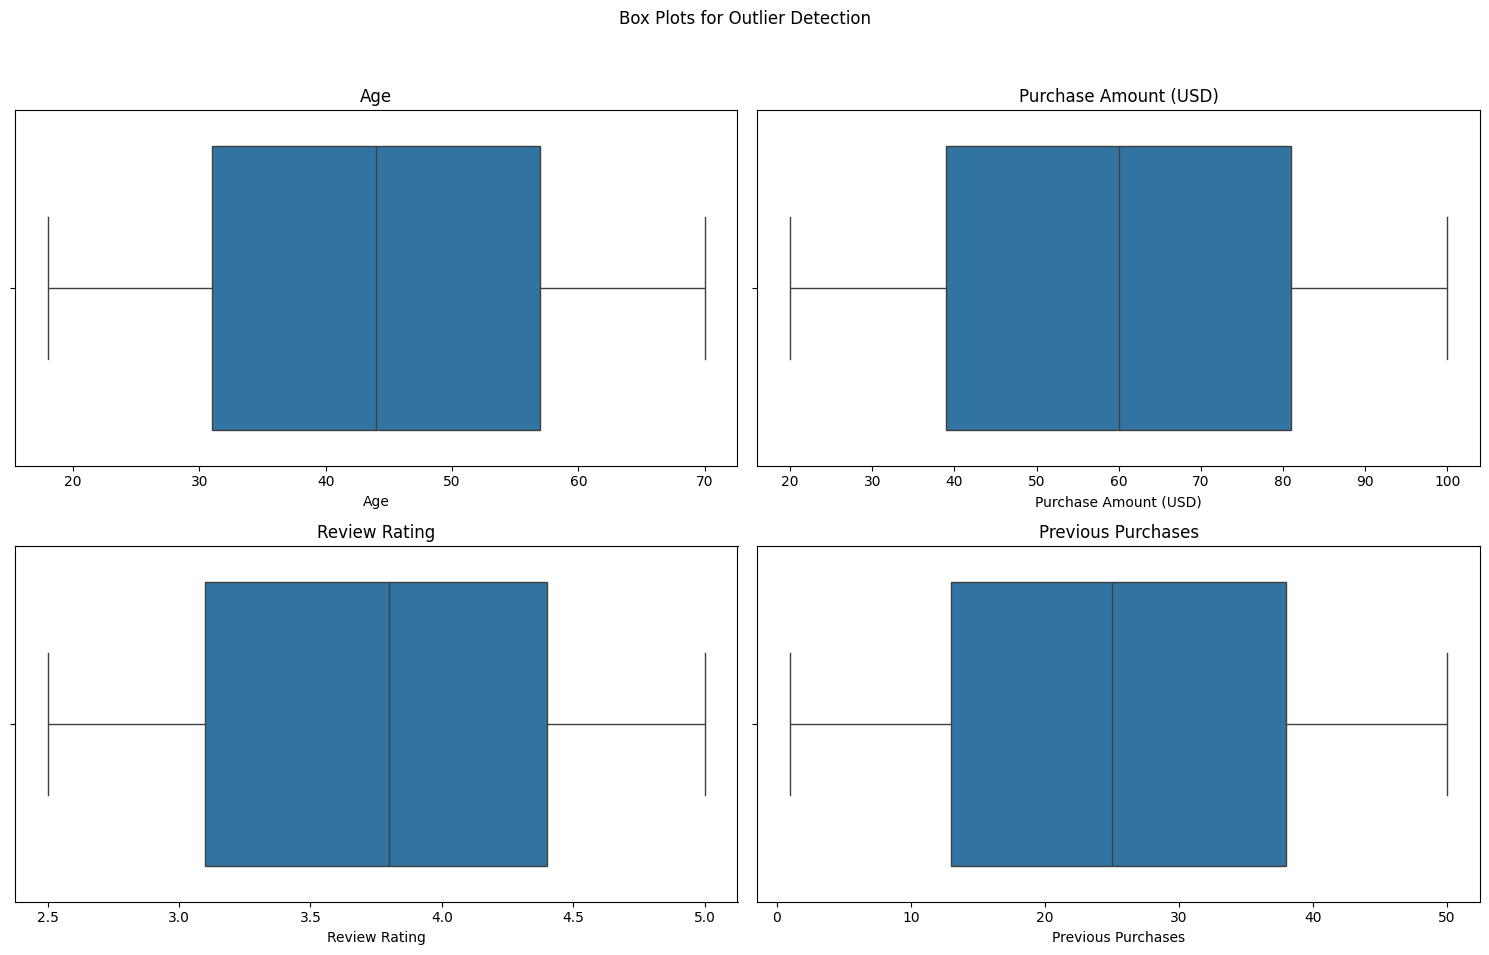

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Box Plots for Outlier Detection')

sns.boxplot(ax=axes[0, 0], x=df['Age'])
axes[0, 0].set_title('Age')

sns.boxplot(ax=axes[0, 1], x=df['Purchase Amount (USD)'])
axes[0, 1].set_title('Purchase Amount (USD)')

sns.boxplot(ax=axes[1, 0], x=df['Review Rating'])
axes[1, 0].set_title('Review Rating')

sns.boxplot(ax=axes[1, 1], x=df['Previous Purchases'])
axes[1, 1].set_title('Previous Purchases')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [8]:
df.drop(columns=['Promo Code Used'], inplace=True)
mask = df['Review Rating'].isnull()
impute_median = df[
    (df['Gender'] == 'Male') & (df['Discount Applied'] == 'Yes')
]['Review Rating'].median()
df.loc[mask, 'Review Rating'] = impute_median

freq_map = {
    'Weekly': 52,
    'Fortnightly': 26,
    'Bi-Weekly': 26,  
    'Monthly': 12,
    'Every 3 Months': 4,
    'Quarterly': 4, 
    'Annually': 1
}
df['Purchase_Frequency_Annual'] = df['Frequency of Purchases'].map(freq_map)

binary_cols = ['Subscription Status', 'Discount Applied']
for col in binary_cols:
    df[col + '_Flag'] = (df[col] == 'Yes').astype(int)

df['Age_Band'] = pd.cut(
    df['Age'],
    bins=[0, 25, 35, 45, 55, 70],
    labels=['18-25', '26-35', '36-45', '46-55', '56-70']
)



In [9]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases,Purchase_Frequency_Annual,Subscription Status_Flag,Discount Applied_Flag,Age_Band
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,Express,Yes,14,Venmo,Fortnightly,26,1,1,46-55
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,Express,Yes,2,Cash,Fortnightly,26,1,1,18-25
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,Free Shipping,Yes,23,Credit Card,Weekly,52,1,1,46-55
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,Next Day Air,Yes,49,PayPal,Weekly,52,1,1,18-25
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,Free Shipping,Yes,31,PayPal,Annually,1,1,1,36-45


In [10]:
df.to_csv(r"C:\Users\HP\OneDrive\Desktop\Customer-Acquisition\Dataset.csv", index=False)